# Repurchase Prediction and Product Recommendation

**Synthetic-data case study.** This notebook estimates when a customer may buy again, recommends what to offer, and combines those outputs into one actionable customer view.

**How to read it:** the first half separates model fitting, validation decisions, and final testing in time. The second half evaluates a simple recommender and combines segment, probability, product, and action into one customer record.

## 1. Repurchase Business Question

Which existing customers are likely to purchase in the next 45 days? The use case is campaign prioritization, where ranking and recall/precision trade-offs matter more than raw accuracy.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Support running from either the repository root or the notebooks folder.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "sample"
ASSET_DIR = PROJECT_ROOT / "assets"
ASSET_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
HORIZON_DAYS = 45

# Load the same deterministic tables used in Notebook 1.
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

## 2. Target Definition

For each cutoff, features use only orders on or before that date. The target is 1 when the customer purchases in the following 45 days. Looking at future transactions while creating features would leak the answer and overstate model performance.

In [2]:
def build_snapshot(cutoff_date: str) -> pd.DataFrame:
    """Build leakage-safe customer features and a forward 45-day label."""
    cutoff = pd.Timestamp(cutoff_date)
    horizon_end = cutoff + pd.Timedelta(days=HORIZON_DAYS)
    # History creates features; the disjoint future window creates only the label.
    history = orders.loc[orders["order_date"].le(cutoff)].copy()
    future = orders.loc[orders["order_date"].gt(cutoff) & orders["order_date"].le(horizon_end)]

    # Lifetime features describe value, frequency, recency, and purchase cadence.
    features = history.groupby("customer_id").agg(
        last_purchase=("order_date", "max"),
        first_purchase=("order_date", "min"),
        frequency=("order_id", "nunique"),
        monetary_value=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
    ).reset_index()
    features["recency_days"] = (cutoff - features["last_purchase"]).dt.days
    features["days_since_first_purchase"] = (cutoff - features["first_purchase"]).dt.days
    features["average_purchase_interval"] = np.where(
        features["frequency"].gt(1),
        features["days_since_first_purchase"] - features["recency_days"],
        np.nan,
    ) / features["frequency"].sub(1).clip(lower=1)

    # Recent-window features capture short-term momentum at the cutoff.
    recent_start = cutoff - pd.Timedelta(days=90)
    recent = history.loc[history["order_date"].gt(recent_start)].groupby("customer_id").agg(
        orders_last_90d=("order_id", "nunique"),
        spend_last_90d=("total_amount", "sum"),
    ).reset_index()

    history_items = (
        history[["order_id", "customer_id"]]
        .merge(order_items, on="order_id")
        .merge(products[["product_id", "category"]], on="product_id")
    )
    diversity = history_items.groupby("customer_id")["category"].nunique().rename("unique_categories").reset_index()

    snapshot = (
        features.merge(recent, on="customer_id", how="left")
        .merge(diversity, on="customer_id", how="left")
        .merge(customers, on="customer_id", how="left")
    )
    snapshot[["orders_last_90d", "spend_last_90d"]] = snapshot[["orders_last_90d", "spend_last_90d"]].fillna(0)
    snapshot["customer_tenure_days"] = (cutoff - snapshot["signup_date"]).dt.days
    # The target is the only field allowed to look beyond the cutoff.
    positive_customers = set(future["customer_id"])
    snapshot["repurchased_45d"] = snapshot["customer_id"].isin(positive_customers).astype(int)
    snapshot["cutoff_date"] = cutoff
    return snapshot

example_snapshot = build_snapshot("2025-09-30")
example_snapshot[["customer_id", "recency_days", "frequency", "repurchased_45d"]].head()

,customer_id,recency_days,frequency,repurchased_45d
0,C0001,30,3,1
1,C0002,12,11,0
2,C0003,48,5,1
3,C0004,421,3,0
4,C0005,369,1,0


## 3. Temporal Train / Validation / Test Split

The chronology mirrors future scoring and keeps decision-making away from the final test period:

- **Train:** four earlier snapshots fit both models. The last training label window ends on 2025-09-29.
- **Validation:** the 2025-09-30 snapshot compares models and selects the campaign threshold; its label window ends on 2025-11-14.
- **Test:** the 2025-11-15 snapshot is evaluated only after the model and threshold are frozen.

Customers may appear in multiple snapshots, but every row uses only information available at its own cutoff. This is valid longitudinal sampling, not leakage.

In [3]:
# Earlier snapshots fit models; later snapshots make and audit decisions.
TRAIN_CUTOFFS = ["2025-02-28", "2025-04-30", "2025-06-30", "2025-08-15"]
VALIDATION_CUTOFF = "2025-09-30"
TEST_CUTOFF = "2025-11-15"

train_data = pd.concat([build_snapshot(date) for date in TRAIN_CUTOFFS], ignore_index=True)
validation_data = build_snapshot(VALIDATION_CUTOFF)

# Assertions prove that label windows do not overlap the next decision period.
latest_train_label_end = max(pd.to_datetime(TRAIN_CUTOFFS)) + pd.Timedelta(days=HORIZON_DAYS)
validation_label_end = pd.Timestamp(VALIDATION_CUTOFF) + pd.Timedelta(days=HORIZON_DAYS)
test_label_end = pd.Timestamp(TEST_CUTOFF) + pd.Timedelta(days=HORIZON_DAYS)
assert latest_train_label_end < pd.Timestamp(VALIDATION_CUTOFF)
assert validation_label_end < pd.Timestamp(TEST_CUTOFF)
assert test_label_end <= orders["order_date"].max()

split_summary = pd.DataFrame({
    "split": ["Train snapshots", "Validation snapshot", "Test snapshot (withheld)"],
    "cutoff_dates": [", ".join(TRAIN_CUTOFFS), VALIDATION_CUTOFF, TEST_CUTOFF],
    "rows": [len(train_data), len(validation_data), "withheld"],
    "label_window_end": [latest_train_label_end, validation_label_end, test_label_end],
})
development_positive_rates = pd.DataFrame({
    "split": ["Train", "Validation"],
    "positive_rate": [train_data["repurchased_45d"].mean(), validation_data["repurchased_45d"].mean()],
})
display(
    split_summary.style.format({"label_window_end": "{:%Y-%m-%d}"}),
    development_positive_rates.style.format({"positive_rate": "{:.1%}"}),
)

,split,cutoff_dates,rows,label_window_end
0,Train snapshots,"2025-02-28, 2025-04-30, 2025-06-30, 2025-08-15",12069,2025-09-29
1,Validation snapshot,2025-09-30,3591,2025-11-14
2,Test snapshot (withheld),2025-11-15,withheld,2025-12-30


,split,positive_rate
0,Train,40.5%
1,Validation,38.8%


In [4]:
numeric_features = [
    "recency_days", "frequency", "monetary_value", "average_order_value",
    "days_since_first_purchase", "average_purchase_interval", "orders_last_90d",
    "spend_last_90d", "unique_categories", "customer_tenure_days",
]
categorical_features = ["country", "acquisition_channel"]
feature_columns = numeric_features + categorical_features

X_train, y_train = train_data[feature_columns], train_data["repurchased_45d"]
X_validation, y_validation = validation_data[feature_columns], validation_data["repurchased_45d"]

# Linear models need scaled numeric inputs and encoded categories.
linear_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
# The histogram model receives a dense encoded matrix.
dense_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

def classification_metrics(y_true, probabilities, threshold=0.50):
    """Return ranking metrics plus classification metrics at one threshold."""
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
    }

## 4. Baseline Model

Logistic Regression is the interpretable baseline. Class weighting keeps the model attentive to the minority positive class.

In [5]:
# Pipeline fitting learns every preprocessing statistic from training rows only.
logistic_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("model", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_model.fit(X_train, y_train)
logistic_validation_probabilities = logistic_model.predict_proba(X_validation)[:, 1]

## 5. Stronger Model

A histogram gradient-boosted tree captures non-linear recency and frequency effects while staying within scikit-learn.

In [6]:
# Use the same train-only fitting rule for the non-linear comparison model.
stronger_model = Pipeline([
    ("preprocess", dense_preprocessor),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.06, max_iter=180, max_leaf_nodes=15,
        min_samples_leaf=35, l2_regularization=1.0, random_state=RANDOM_STATE,
    )),
])
stronger_model.fit(X_train, y_train)
stronger_validation_probabilities = stronger_model.predict_proba(X_validation)[:, 1]

## 6. Validation Model Comparison

Both models are fitted only on training snapshots. Model selection uses the later validation snapshot, with PR-AUC as the primary ranking metric because repurchasers are the positive class of interest. The test snapshot remains untouched during this decision.

In [7]:
# Compare out-of-time validation performance before revealing the test snapshot.
validation_model_results = pd.DataFrame([
    {"Model": "Logistic Regression", **classification_metrics(y_validation, logistic_validation_probabilities)},
    {"Model": "Gradient Boosting", **classification_metrics(y_validation, stronger_validation_probabilities)},
]).set_index("Model")

# PR-AUC is the selection metric because positive repurchases are the rarer class.
selected_model_name = validation_model_results["PR-AUC"].idxmax()
if selected_model_name == "Gradient Boosting":
    selected_model = stronger_model
    validation_probabilities = stronger_validation_probabilities
else:
    selected_model = logistic_model
    validation_probabilities = logistic_validation_probabilities

print(f"Selected model from validation PR-AUC: {selected_model_name}")
validation_model_results.round(3)

Selected model from validation PR-AUC: Gradient Boosting


,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.601,0.725,0.657,0.792,0.667
Gradient Boosting,0.670,0.575,0.619,0.805,0.686


## 7. Validation Threshold Selection

The default 0.50 threshold is only a reference point. On validation data, we choose the highest-precision threshold that achieves at least 70% recall for a low-cost retention campaign. That threshold is then frozen and applied once to the final future test snapshot; test outcomes cannot change the decision.

In [8]:
# Search candidate operating points using validation probabilities only.
thresholds = np.arange(0.10, 0.81, 0.02)
threshold_rows = []
for threshold in thresholds:
    validation_predictions = validation_probabilities >= threshold
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, validation_predictions, zero_division=0),
        "recall": recall_score(y_validation, validation_predictions, zero_division=0),
        "f1": f1_score(y_validation, validation_predictions, zero_division=0),
        "predicted_positive_rate": validation_predictions.mean(),
    })
validation_threshold_table = pd.DataFrame(threshold_rows)
eligible_thresholds = validation_threshold_table.loc[validation_threshold_table["recall"].ge(0.70)]

# Prefer precision after meeting the campaign's minimum 70% recall requirement.
if eligible_thresholds.empty:
    selected_row = validation_threshold_table.sort_values(["recall", "precision"], ascending=False).iloc[0]
    threshold_selection_note = "No candidate reached 70% validation recall; selected the highest-recall candidate."
else:
    selected_row = eligible_thresholds.sort_values(["precision", "threshold"], ascending=False).iloc[0]
    threshold_selection_note = "Selected the highest-precision candidate with at least 70% validation recall."

selected_threshold = float(selected_row["threshold"])
validation_selected_metrics = classification_metrics(y_validation, validation_probabilities, selected_threshold)
# Freeze the decision before any test probabilities are generated.
frozen_threshold = selected_threshold

selected_index = validation_threshold_table["threshold"].sub(selected_threshold).abs().idxmin()
threshold_neighborhood = validation_threshold_table.loc[
    max(0, selected_index - 2): min(len(validation_threshold_table) - 1, selected_index + 2)
]

print(f"{threshold_selection_note} Frozen threshold: {frozen_threshold:.2f}")
display(
    threshold_neighborhood.round(3),
    pd.DataFrame([validation_selected_metrics], index=[f"Validation @ {frozen_threshold:.2f}"]).round(3),
)

Selected the highest-precision candidate with at least 70% validation recall. Frozen threshold: 0.42


,threshold,precision,recall,f1,predicted_positive_rate
14,0.38,0.602,0.781,0.680,0.504
15,0.40,0.615,0.735,0.669,0.464
16,0.42,0.628,0.700,0.662,0.433
17,0.44,0.638,0.668,0.653,0.406
18,0.46,0.645,0.628,0.636,0.378


,Precision,Recall,F1,ROC-AUC,PR-AUC
Validation @ 0.42,0.628,0.7,0.662,0.805,0.686


## 8. Final Test Evaluation

Only now—after the model and threshold are frozen—do we generate predictions for the latest test snapshot. The default 0.50 row is a reference; the campaign estimate uses the validation-selected threshold. No test result feeds back into model or threshold selection.

Final test positive rate: 38.0%


,Precision,Recall,F1,ROC-AUC,PR-AUC
Test @ 0.50,0.661,0.583,0.619,0.809,0.687
Test @ frozen 0.42,0.616,0.709,0.659,0.809,0.687


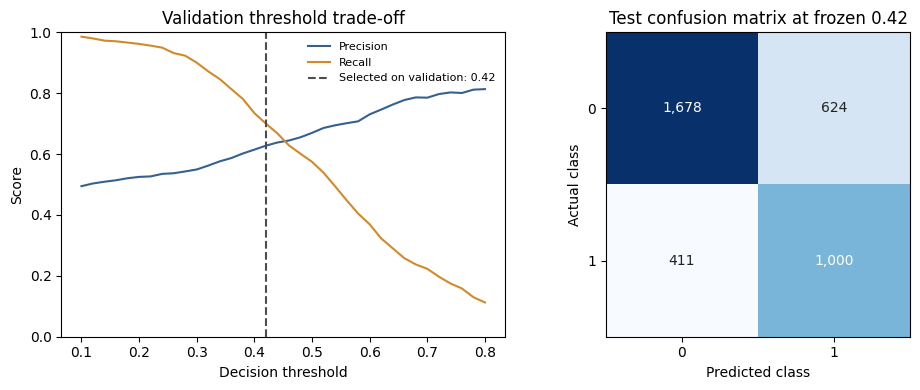

In [9]:
# The test snapshot is materialized only after model and threshold selection.
test_data = build_snapshot(TEST_CUTOFF)
X_test = test_data[feature_columns]
y_test = test_data["repurchased_45d"]
test_probabilities = selected_model.predict_proba(X_test)[:, 1]

test_default_metrics = classification_metrics(y_test, test_probabilities, threshold=0.50)
# Apply the frozen validation threshold exactly once for the final estimate.
test_selected_metrics = classification_metrics(y_test, test_probabilities, threshold=frozen_threshold)
test_predictions = (test_probabilities >= frozen_threshold).astype(int)
test_matrix = confusion_matrix(y_test, test_predictions)

print(f"Final test positive rate: {y_test.mean():.1%}")
display(pd.DataFrame(
    [test_default_metrics, test_selected_metrics],
    index=["Test @ 0.50", f"Test @ frozen {frozen_threshold:.2f}"],
).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(validation_threshold_table["threshold"], validation_threshold_table["precision"], label="Precision", color="#35618f")
axes[0].plot(validation_threshold_table["threshold"], validation_threshold_table["recall"], label="Recall", color="#d08b29")
axes[0].axvline(frozen_threshold, color="#4d4d4d", linestyle="--", label=f"Selected on validation: {frozen_threshold:.2f}")
axes[0].set(title="Validation threshold trade-off", xlabel="Decision threshold", ylabel="Score", ylim=(0, 1))
axes[0].legend(frameon=False, fontsize=8)

axes[1].imshow(test_matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(test_matrix):
    axes[1].text(column, row, f"{value:,}", ha="center", va="center", color="white" if value > test_matrix.max() / 2 else "#222222")
axes[1].set(
    title=f"Test confusion matrix at frozen {frozen_threshold:.2f}",
    xlabel="Predicted class", ylabel="Actual class", xticks=[0, 1], yticks=[0, 1],
)
fig.tight_layout()
fig.savefig(ASSET_DIR / "model_evaluation.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Product Recommendation

The recommender is intentionally simple: infer each customer's category affinity, then rank popular products inside those categories. Repeat products are allowed because replenishment is a valid e-commerce use case. A leave-last-order-out check reports HitRate@3; it is directional on synthetic data, not an online impact estimate.

In [10]:
# Restrict recommendation history to information available by the test cutoff.
dated_items = (
    order_items.merge(orders[["order_id", "customer_id", "order_date"]], on="order_id")
    .merge(products[["product_id", "product_name", "category"]], on="product_id")
)
recommendation_history = dated_items.loc[dated_items["order_date"].le(pd.Timestamp(TEST_CUTOFF))].copy()
order_sequence = (
    recommendation_history[["customer_id", "order_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["customer_id", "order_date", "order_id"])
)
eligible_customers = order_sequence.groupby("customer_id").size().loc[lambda values: values.ge(3)].index
# Hold out each sampled customer's last order to simulate a future basket.
last_orders = order_sequence.loc[order_sequence["customer_id"].isin(eligible_customers)].groupby("customer_id").tail(1)
evaluation_customers = last_orders.sample(min(600, len(last_orders)), random_state=RANDOM_STATE)
holdout_pairs = pd.MultiIndex.from_frame(evaluation_customers[["customer_id", "order_id"]])
history_pairs = pd.MultiIndex.from_frame(recommendation_history[["customer_id", "order_id"]])
recommender_train = recommendation_history.loc[~history_pairs.isin(holdout_pairs)].copy()

category_affinity = recommender_train.groupby(["customer_id", "category"])["quantity"].sum()
category_popularity = (
    recommender_train.groupby(["category", "product_id", "product_name"])["quantity"]
    .sum().rename("units").reset_index()
    .sort_values(["category", "units"], ascending=[True, False])
)
overall_popularity = (
    recommender_train.groupby(["product_id", "product_name"])["quantity"]
    .sum().sort_values(ascending=False).reset_index()
)

def recommend_products(customer_id: str, k: int = 3) -> list[str]:
    """Rank popular products in preferred categories, then use global fallback."""
    recommendations = []
    if customer_id in category_affinity.index.get_level_values(0):
        preferred_categories = category_affinity.loc[customer_id].sort_values(ascending=False).index
        for category in preferred_categories:
            candidates = category_popularity.loc[category_popularity["category"].eq(category), "product_name"]
            for product_name in candidates:
                if product_name not in recommendations:
                    recommendations.append(product_name)
                if len(recommendations) == k:
                    return recommendations
    for product_name in overall_popularity["product_name"]:
        if product_name not in recommendations:
            recommendations.append(product_name)
        if len(recommendations) == k:
            break
    return recommendations

# HitRate@3 asks whether any recommendation appears in the held-out order.
held_out_products = recommendation_history.merge(
    evaluation_customers[["customer_id", "order_id"]], on=["customer_id", "order_id"]
).groupby("customer_id")["product_name"].apply(set)
hits = []
for customer_id, actual_products in held_out_products.items():
    recommended = set(recommend_products(customer_id, k=3))
    hits.append(bool(recommended & actual_products))
hit_rate_at_3 = float(np.mean(hits))
print(f"Leave-last-order-out HitRate@3: {hit_rate_at_3:.1%} across {len(hits):,} synthetic customers")

Leave-last-order-out HitRate@3: 19.8% across 600 synthetic customers


## 10. Example Customer Output

This compact record connects **WHO → WHEN → WHAT → ACTION**.

In [11]:
# Recreate Notebook 1's five-cluster segmentation on full-history SQL features.
# Keeping this local makes Notebook 2 independently executable.
connection = sqlite3.connect(":memory:")
customers.assign(signup_date=customers["signup_date"].dt.strftime("%Y-%m-%d")).to_sql("customers", connection, index=False)
products.to_sql("products", connection, index=False)
orders.assign(order_date=orders["order_date"].dt.strftime("%Y-%m-%d")).to_sql("orders", connection, index=False)
order_items.to_sql("order_items", connection, index=False)
full_features = pd.read_sql_query((PROJECT_ROOT / "sql" / "customer_features.sql").read_text(), connection)
connection.close()

segment_columns = ["recency_days", "frequency", "monetary_value", "average_order_value", "days_since_first_purchase", "average_purchase_interval", "unique_categories"]
segment_frame = full_features[segment_columns].copy()
segment_frame["average_purchase_interval"] = segment_frame["average_purchase_interval"].fillna(segment_frame["average_purchase_interval"].median())
skewed = ["recency_days", "frequency", "monetary_value", "average_order_value", "average_purchase_interval"]
segment_frame[skewed] = np.log1p(segment_frame[skewed])
segment_scaled = StandardScaler().fit_transform(segment_frame)
full_features["cluster"] = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20).fit_predict(segment_scaled)
profiles = full_features.groupby("cluster").agg(
    average_recency=("recency_days", "mean"), average_frequency=("frequency", "mean"),
    average_monetary_value=("monetary_value", "mean"), average_tenure=("days_since_first_purchase", "mean"),
)
z = (profiles - profiles.mean()) / profiles.std(ddof=0)
remaining = set(profiles.index)
high_value = (z["average_frequency"] + z["average_monetary_value"] - z["average_recency"]).idxmax(); remaining.remove(high_value)
at_risk = z.loc[list(remaining), "average_recency"].idxmax(); remaining.remove(at_risk)
new_promising = z.loc[list(remaining), "average_tenure"].idxmin(); remaining.remove(new_promising)
low_frequency = (z.loc[list(remaining), "average_frequency"] + z.loc[list(remaining), "average_monetary_value"]).idxmin(); remaining.remove(low_frequency)
segment_map = {high_value: "High Value Loyal", remaining.pop(): "Loyal Customers", new_promising: "New / Promising", at_risk: "At Risk", low_frequency: "Low Frequency"}
full_features["segment"] = full_features["cluster"].map(segment_map)

# Join WHO (segment) with WHEN (probability), WHAT (products), and ACTION.
scored_customers = test_data[["customer_id"]].copy()
scored_customers["repurchase_probability"] = test_probabilities
scored_customers = scored_customers.merge(full_features[["customer_id", "segment"]], on="customer_id")
example_customer = scored_customers.sort_values("repurchase_probability", ascending=False).iloc[25]
recommendations = recommend_products(example_customer["customer_id"], 3)
action_by_segment = {
    "High Value Loyal": "VIP retention and personalized cross-sell",
    "Loyal Customers": "Loyalty reward and replenishment reminder",
    "New / Promising": "Second-order onboarding offer",
    "At Risk": "Reactivation campaign",
    "Low Frequency": "Low-cost nurture campaign",
}
customer_intelligence_output = pd.DataFrame({
    "Field": ["Customer ID", "Segment", "Repurchase probability", "Recommended products", "Suggested business action"],
    "Value": [example_customer["customer_id"], example_customer["segment"], f"{example_customer['repurchase_probability']:.1%}", " | ".join(recommendations), action_by_segment[example_customer["segment"]]],
})
customer_intelligence_output

,Field,Value
0,Customer ID,C3765
1,Segment,High Value Loyal
2,Repurchase probability,88.3%
3,Recommended products,Sports Item 02 | Sports Item 01 | Sports Item 03
4,Suggested business action,VIP retention and personalized cross-sell


## 11. Production Monitoring

- **Model:** PR-AUC, precision, recall, calibration, and the prediction distribution.
- **System:** scoring/API latency, error rate, and uptime.
- **Data and model drift:** customer-feature distributions, category mix, prediction drift, and delayed-label performance degradation.
- **Business:** conversion, repurchase rate, revenue per customer, campaign uplift, recommendation CTR, and incremental revenue.

A lightweight batch score or API could be containerized, but infrastructure is intentionally outside this portfolio scope. Online A/B testing is required to establish causal business impact.

## 12. Final Takeaways

- Temporal snapshots keep future purchases out of feature engineering.
- Models fit only on past training snapshots; validation selects the model and campaign threshold.
- The frozen decisions are evaluated once on the latest test snapshot for an unbiased final estimate.
- Thresholds should reflect campaign economics, while recommendation quality ultimately needs online validation.